In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("fixed_final_data_product.csv")

print(df.columns)
df.info()
df.describe()

print(df.shape)

Index(['lap_id', 'invalid_lap', 'BPS_SPEED', 'BPS_THROTTLE', 'BPS_STEER',
       'BPS_BRAKE', 'BPS_CURRENTLAPTIMEINMS', 'BPS_LAPDISTANCE',
       'BPS_WORLDPOSITIONX', 'BPS_WORLDPOSITIONY',
       ...
       'dist_530_YAW', 'dist_530_PITCH', 'dist_530_ROLL', 'dist_530_left_dist',
       'dist_530_right_dist', 'dist_530_dist_apex_1', 'dist_530_dist_apex_2',
       'dist_530_angle_to_apex1', 'dist_530_angle_to_apex2',
       'dist_530_proj_from_ref'],
      dtype='object', length=255)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Columns: 255 entries, lap_id to dist_530_proj_from_ref
dtypes: float64(242), int64(12), object(1)
memory usage: 2.0+ MB
(1032, 255)


## Model

Cleaning dataset - finding  cols with missing vals and putting vals into those

In [3]:
print(f"Rows (n): {df.shape[0]}")
print(f"Features (p): {df.shape[1]}")

Rows (n): 1032
Features (p): 255


In [4]:
df = df.drop(columns=['lap_id'])

# Remove any null values
df = df.dropna()

# Remove laps that are too slow using IQR
Q1 = df['Target_CURRENTLAPTIMEINMS'].quantile(0.25)
Q3 = df['Target_CURRENTLAPTIMEINMS'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Target_CURRENTLAPTIMEINMS'] <= upper_bound)]

# Keep driver related behavioral features
behavioural_keywords = ['BPS_SPEED', 'BPS_THROTTLE', 'BPS_STEER', 'BPS_BRAKE', 'BPS_CURRENTLAPTIMEINMS', 
             'BPS_LAPDISTANCE', 'BPS_WORLDPOSITIONX', 'BPS_WORLDPOSITIONY', 'BPE_SPEED', 'BPE_THROTTLE', 
             'BPE_STEER', 'BPE_BRAKE', 'BPE_CURRENTLAPTIMEINMS', 'BPE_LAPDISTANCE', 'BPE_WORLDPOSITIONX', 'BPE_WORLDPOSITIONY',
            'THS_SPEED', 'THS_THROTTLE', 'THS_STEER', 'THS_BRAKE', 'THS_CURRENTLAPTIMEINMS', 'THS_LAPDISTANCE', 'THS_WORLDPOSITIONX', 
             'THS_WORLDPOSITIONY', 'THE_SPEED', 'THE_THROTTLE', 'THE_STEER', 'THE_BRAKE', 'THE_CURRENTLAPTIMEINMS', 
             'THE_LAPDISTANCE', 'THE_WORLDPOSITIONX', 'THE_WORLDPOSITIONY', 'STS_SPEED', 'STS_THROTTLE', 'STS_STEER', 'STS_BRAKE', 
             'STS_CURRENTLAPTIMEINMS', 'STS_LAPDISTANCE', 'STS_WORLDPOSITIONX', 'STS_WORLDPOSITIONY', 'STM_SPEED', 'STM_THROTTLE', 
             'STM_STEER', 'STM_BRAKE', 'STM_CURRENTLAPTIMEINMS', 'STM_LAPDISTANCE', 'STM_WORLDPOSITIONX', 'STM_WORLDPOSITIONY', 
            'STE_SPEED', 'STE_THROTTLE', 'STE_STEER', 'STE_BRAKE', 'STE_CURRENTLAPTIMEINMS', 'STE_LAPDISTANCE', 'STE_WORLDPOSITIONX', 
             'STE_WORLDPOSITIONY', 'Target_CURRENTLAPTIMEINMS']

df = df[[col for col in behavioural_keywords if col in df.columns]]

# Defining X and y feature and target
X = df.drop(columns=['Target_CURRENTLAPTIMEINMS'])
y = df['Target_CURRENTLAPTIMEINMS']

In [5]:
print(f"Rows (n): {X.shape[0]}")
print(f"Features (p): {X.shape[1]}")

Rows (n): 729
Features (p): 56


## Random Forest

MSE:  116485.86500795081
RMSE:  341.30025638424416
MAE:  192.57590378343116
Adjusted R squared:  0.8177875077718496


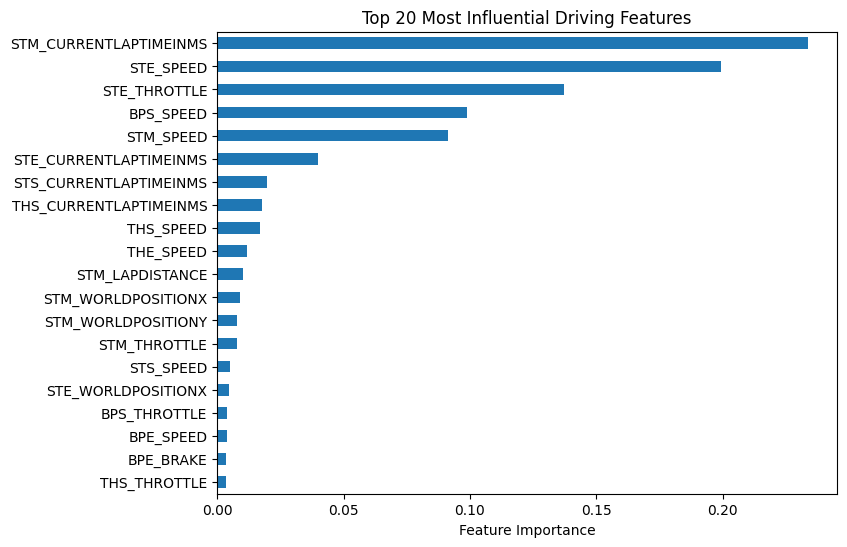

In [6]:
# Split data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test) # Predict the target values of the test set

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r_squared = 1 - (1 - r_squared) * ((n - 1) / (n - p - 1))

print("MSE: ", mse)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("Adjusted R squared: ", adjusted_r_squared)


# Get feature importance - Which driving behaviours mattered most
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
top_20.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Most Influential Driving Features")
plt.xlabel("Feature Importance")
plt.show()


In [7]:
# Group features into categories
groups = {
    "Brake": [col for col in X.columns if "_BRAKE" in col],
    "Throttle": [col for col in X.columns if "_THROTTLE" in col],
    "Steer": [col for col in X.columns if "_STEER" in col],
    "Speed": [col for col in X.columns if "_SPEED" in col]
}

group_importance = {g: importances[cols].sum() for g, cols in groups.items()}
pd.Series(group_importance).sort_values(ascending=False)

Speed       0.427493
Throttle    0.156163
Steer       0.020953
Brake       0.009878
dtype: float64

## Using GridSearchCV to tune parameters

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
